# Visualisations: Department and length of stay

**Which department produces the longest length of stay (LOS), and which factors are most related to long stays inside that department?**


In [71]:
#needed

import csv
import itertools
import math
import statistics
from collections import defaultdict
from pathlib import Path
from typing import Any

csv_file = Path("Topic3_healthcare_analytics_dataset.csv")

# The CSV stores stay length and age as interval labels, not exact numbers.
# These lists keep the labels in the correct order for charts and tables.
stay_order = [
    "0-10",
    "11-20",
    "21-30",
    "31-40",
    "41-50",
    "51-60",
    "61-70",
    "71-80",
    "81-90",
    "91-100",
    "More than 100 Days",
]

# Midpoints turn interval labels into approximate numbers.
# Example: "41-50" becomes 45.5 days.
stay_midpoints = {
    "0-10": 5.0,
    "11-20": 15.5,
    "21-30": 25.5,
    "31-40": 35.5,
    "41-50": 45.5,
    "51-60": 55.5,
    "61-70": 65.5,
    "71-80": 75.5,
    "81-90": 85.5,
    "91-100": 95.5,
    "More than 100 Days": 110.0,
}

age_midpoints = {
    "0-10": 5.0,
    "11-20": 15.5,
    "21-30": 25.5,
    "31-40": 35.5,
    "41-50": 45.5,
    "51-60": 55.5,
    "61-70": 65.5,
    "71-80": 75.5,
    "81-90": 85.5,
    "91-100": 95.5,
}

# These are the numeric features we compare with length of stay.
correlation_features = [
    "age_midpoint",
    "Available Extra Rooms in Hospital",
    "Visitors with Patient",
    "Admission_Deposit",
    "Bed Grade",
]

# Shorter labels make the charts easier to read.
feature_labels = {
    "age_midpoint": "Age midpoint",
    "Available Extra Rooms in Hospital": "Available extra rooms",
    "Visitors with Patient": "Visitors with patient",
    "Admission_Deposit": "Admission deposit",
    "Bed Grade": "Bed grade",
}

## 1. Load and prepare the data

The dataset stores `Stay` as categories such as `0-10` and `41-50`. For averages and correlations, each stay category is converted into an approximate midpoint in days.

In [70]:
#needed

def to_number(value: Any) -> float | None:
    """Change one CSV value into a number. If this is not possible, return None."""
    text = "" if value is None else str(value).strip()
    if text == "":
        return None
    try:
        number = float(text)
    except ValueError:
        return None
    if math.isnan(number):
        return None
    return number

print(to_number("42"))

42.0


In [69]:
#needed

def load_prepared_rows(csv_path: Path = csv_file) -> list[dict[str, Any]]:
    """Load the CSV and add the extra numeric columns that are needed for the analysis."""
    with csv_path.open(newline="", encoding="utf-8") as file:
        reader = csv.DictReader(file)
        rows = []
        for row in reader:
            clean_row = {key: ("" if value is None else str(value).strip()) for key, value in row.items()}

            # Add numeric versions of Stay and Age so we can calculate averages and correlations.
            clean_row["stay_days"] = stay_midpoints.get(clean_row["Stay"])
            clean_row["age_midpoint"] = age_midpoints.get(clean_row["Age"])

            # Convert the other selected correlation features from text to numbers.
            for column in [
                "Available Extra Rooms in Hospital",
                "Visitors with Patient",
                "Admission_Deposit",
                "Bed Grade",
            ]:
                clean_row[column] = to_number(clean_row[column])

            rows.append(clean_row)
    return rows

rows = load_prepared_rows(csv_file)
print(f"Rows loaded: {len(rows):,}")

Rows loaded: 313,793


## 2. Find the department with the longest average LOS

This step answers the main project question directly by ranking departments by average stay length.

In [68]:
#needed

def mean(values: list[float]) -> float:
    """Calculate the average of a list of numbers."""
    return sum(values) / len(values)

print(mean([10.0, 20.0, 30.0]))

20.0


In [67]:
#needed

def get_department_los_summary(rows: list[dict[str, Any]]) -> list[dict[str, Any]]:
    """Group patients by department and calculate the LOS summary for each department."""
    grouped_stays = defaultdict(list)
    for row in rows:
        if row["stay_days"] is not None:
            grouped_stays[row["Department"]].append(row["stay_days"])

    summary = []
    for department, stay_values in grouped_stays.items():
        summary.append(
            {
                "department": department,
                "patients": len(stay_values),
                "mean_stay_days": mean(stay_values),
                "median_stay_days": statistics.median(stay_values),
            }
        )

    # The first row after sorting is the department with the longest average LOS.
    return sorted(summary, key=lambda row: row["mean_stay_days"], reverse=True)

department_los = get_department_los_summary(rows)
longest_los_department = department_los[0]["department"]
longest_los_days = department_los[0]["mean_stay_days"]

for row in department_los:
    print(
        f"{row['department']:20} "
        f"patients={row['patients']:7,} "
        f"mean={row['mean_stay_days']:5.1f} days "
        f"median={row['median_stay_days']:5.1f} days"
    )

print(f"\nLongest average LOS: {longest_los_department} ({longest_los_days:.1f} days)")

surgery              patients=  1,143 mean= 38.1 days median= 35.5 days
radiotherapy         patients= 28,153 mean= 33.7 days median= 25.5 days
gynecology           patients=245,850 mean= 32.6 days median= 25.5 days
TB & Chest disease   patients=  9,460 mean= 31.4 days median= 25.5 days
anesthesia           patients= 29,187 mean= 30.6 days median= 25.5 days

Longest average LOS: surgery (38.1 days)


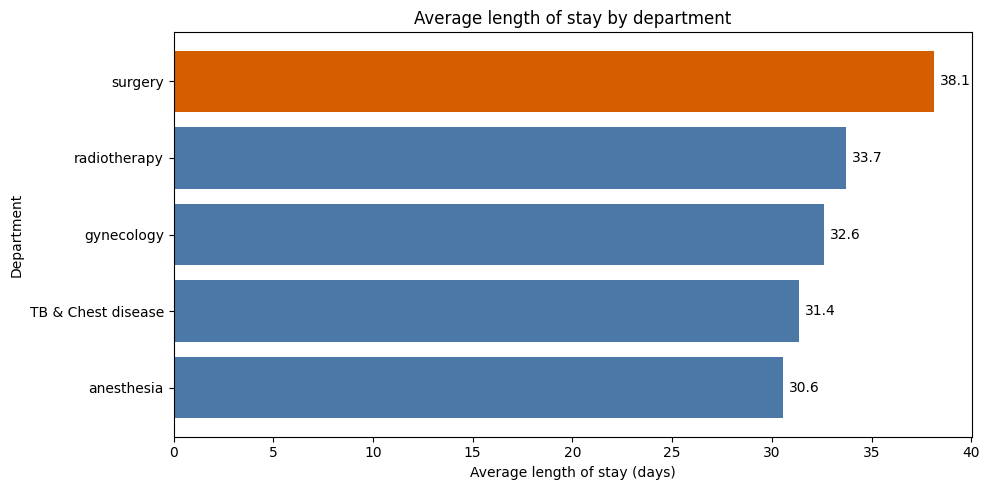

In [66]:
def show_department_los_chart(department_los: list[dict[str, Any]]) -> None:
    """Draw a bar chart that compares the average LOS of all departments."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("This visualisation needs matplotlib. Please run it in a notebook environment with matplotlib installed.")
        return

    plot_rows = sorted(department_los, key=lambda row: row["mean_stay_days"])
    departments = [row["department"] for row in plot_rows]
    mean_stays = [row["mean_stay_days"] for row in plot_rows]
    colors = ["#d55e00" if department == longest_los_department else "#4c78a8" for department in departments]

    _, axis = plt.subplots(figsize=(10, 5))
    axis.barh(departments, mean_stays, color=colors)
    axis.set_title("Average length of stay by department")
    axis.set_xlabel("Average length of stay (days)")
    axis.set_ylabel("Department")

    # Put the exact average LOS next to each bar so the chart is easy to present.
    for department, value in zip(departments, mean_stays):
        axis.text(value + 0.3, department, f"{value:.1f}", va="center")

    plt.tight_layout()
    plt.show()

show_department_los_chart(department_los)

## 3. Direct correlations inside the longest-stay department

Now we only look at the department with the longest average LOS. Direct correlations show which individual numeric variables move together with LOS inside that department.

In [64]:
#needed

def pearson_correlation(first_values: list[float], second_values: list[float]) -> float | None:
    """Measure how strongly two numeric lists move together. The result is between -1 and 1."""
    pairs = [(x, y) for x, y in zip(first_values, second_values) if x is not None and y is not None]
    if len(pairs) < 2:
        return None

    x_values = [pair[0] for pair in pairs]
    y_values = [pair[1] for pair in pairs]
    x_mean = mean(x_values)
    y_mean = mean(y_values)

    numerator = sum((x - x_mean) * (y - y_mean) for x, y in pairs)
    x_denominator = math.sqrt(sum((x - x_mean) ** 2 for x in x_values))
    y_denominator = math.sqrt(sum((y - y_mean) ** 2 for y in y_values))

    if x_denominator == 0 or y_denominator == 0:
        return None
    return numerator / (x_denominator * y_denominator)

print(pearson_correlation([1.0, 2.0, 3.0], [1.0, 2.0, 4.0]))

0.9819805060619655


In [63]:
#needed

def get_direct_correlations(rows: list[dict[str, Any]], department: str) -> list[dict[str, Any]]:
    """Calculate how each single feature is related to LOS inside one department."""
    department_rows = [row for row in rows if row["Department"] == department]
    stay_values = [row["stay_days"] for row in department_rows]

    results = []
    for feature in correlation_features:
        feature_values = [row[feature] for row in department_rows]
        correlation = pearson_correlation(feature_values, stay_values)
        results.append(
            {
                "feature": feature,
                "label": feature_labels[feature],
                "correlation": correlation,
            }
        )

    # Sort by absolute value so the strongest positive or negative relationships appear first.
    return sorted(results, key=lambda row: abs(row["correlation"] or 0), reverse=True)

direct_correlations = get_direct_correlations(rows, longest_los_department)

for row in direct_correlations:
    print(f"{row['label']:30} correlation={row['correlation']:6.3f}")

Visitors with patient          correlation= 0.600
Available extra rooms          correlation=-0.192
Bed grade                      correlation=-0.132
Admission deposit              correlation=-0.070
Age midpoint                   correlation=-0.059


## 4. Visualise direct correlations

The bar chart ranks the direct correlations. The scatterplot shows the strongest direct factor against LOS.

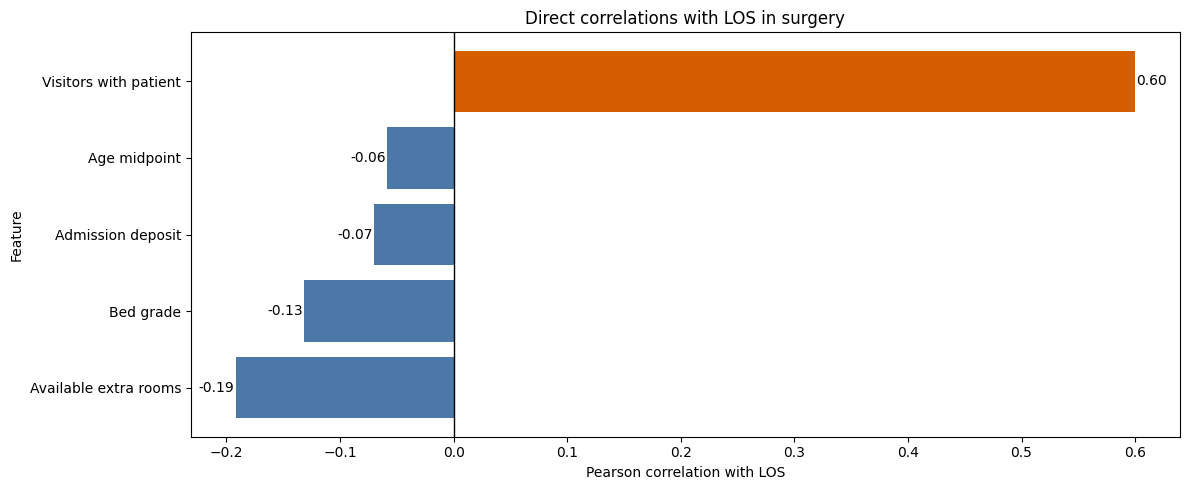

In [62]:
def show_direct_correlation_chart(direct_correlations: list[dict[str, Any]]) -> None:
    """Draw a bar chart of direct correlations with LOS for the longest-stay department."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("This visualisation needs matplotlib. Please run it in a notebook environment with matplotlib installed.")
        return

    plot_rows = sorted(direct_correlations, key=lambda row: row["correlation"] or 0)
    labels = [row["label"] for row in plot_rows]
    values = [row["correlation"] or 0 for row in plot_rows]
    colors = ["#d55e00" if value > 0 else "#4c78a8" for value in values]

    _, axis = plt.subplots(figsize=(12, 5))
    axis.barh(labels, values, color=colors)
    axis.axvline(0, color="black", linewidth=1)
    axis.set_title(f"Direct correlations with LOS in {longest_los_department}")
    axis.set_xlabel("Pearson correlation with LOS")
    axis.set_ylabel("Feature")

    for i, (label,value) in enumerate(zip(labels, values)):
        text_position = value + 0.001 if value >= 0 else value - 0.001
        alignment = "left" if value >= 0 else "right"
        axis.text(text_position, i , f"{value:.2f}", va="center", ha=alignment)

    plt.tight_layout()
    plt.show()

show_direct_correlation_chart(direct_correlations)

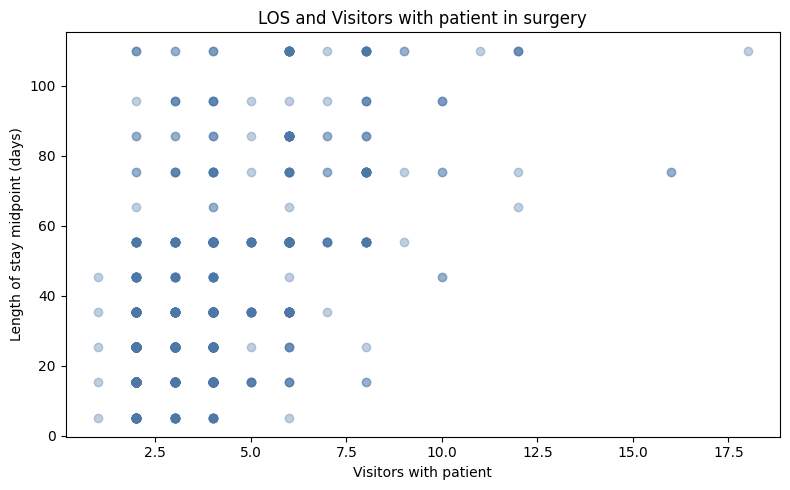

In [61]:
def show_strongest_direct_scatter(rows: list[dict[str, Any]], direct_correlations: list[dict[str, Any]]) -> None:
    """Draw a scatterplot for the feature with the strongest direct LOS correlation."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("This visualisation needs matplotlib. Please run it in a notebook environment with matplotlib installed.")
        return

    strongest_feature = direct_correlations[0]["feature"]
    strongest_label = direct_correlations[0]["label"]
    department_rows = [row for row in rows if row["Department"] == longest_los_department]

    x_values = [row[strongest_feature] for row in department_rows if row[strongest_feature] is not None]
    y_values = [row["stay_days"] for row in department_rows if row[strongest_feature] is not None]

    _, axis = plt.subplots(figsize=(8, 5))
    axis.scatter(x_values, y_values, alpha=0.35, color="#4c78a8")
    axis.set_title(f"LOS and {strongest_label} in {longest_los_department}")
    axis.set_xlabel(strongest_label)
    axis.set_ylabel("Length of stay midpoint (days)")

    plt.tight_layout()
    plt.show()

show_strongest_direct_scatter(rows, direct_correlations)

## 5. Second-order correlations inside the longest-stay department

Second-order correlations check combinations of two variables. The interaction value is calculated by multiplying the two variables, then correlating that product with LOS.

In [60]:
#needed

def get_second_order_correlations(rows: list[dict[str, Any]], department: str) -> list[dict[str, Any]]:
    """Calculate how pairs of features together are related to LOS inside one department."""
    department_rows = [row for row in rows if row["Department"] == department]
    stay_values = [row["stay_days"] for row in department_rows]

    results = []
    for first_feature, second_feature in itertools.combinations(correlation_features, 2):
        interaction_values = []
        for row in department_rows:
            first_value = row[first_feature]
            second_value = row[second_feature]
            if first_value is None or second_value is None:
                interaction_values.append(None)
            else:
                # The interaction is the product of two features, for example visitors * deposit.
                interaction_values.append(first_value * second_value)

        correlation = pearson_correlation(interaction_values, stay_values)
        results.append(
            {
                "interaction": f"{feature_labels[first_feature]} x {feature_labels[second_feature]}",
                "correlation": correlation,
            }
        )

    return sorted(results, key=lambda row: abs(row["correlation"] or 0), reverse=True)

second_order_correlations = get_second_order_correlations(rows, longest_los_department)

for row in second_order_correlations:
    print(f"{row['interaction']:65} correlation={row['correlation']:6.3f}")

Visitors with patient x Admission deposit                         correlation= 0.514
Age midpoint x Visitors with patient                              correlation= 0.387
Visitors with patient x Bed grade                                 correlation= 0.374
Available extra rooms x Visitors with patient                     correlation= 0.326
Available extra rooms x Bed grade                                 correlation=-0.214
Available extra rooms x Admission deposit                         correlation=-0.179
Age midpoint x Available extra rooms                              correlation=-0.145
Admission deposit x Bed grade                                     correlation=-0.140
Age midpoint x Bed grade                                          correlation=-0.120
Age midpoint x Admission deposit                                  correlation=-0.091


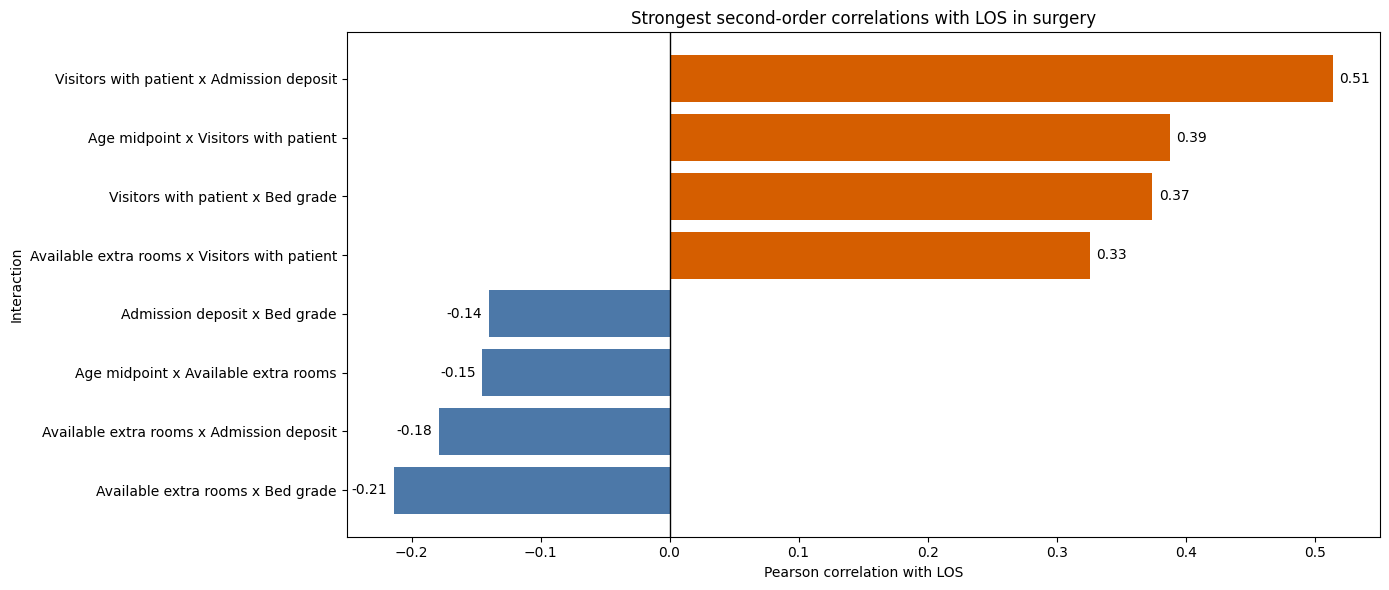

In [56]:
def show_second_order_correlation_chart(second_order_correlations: list[dict[str, Any]], limit: int = 8) -> None:
    """Draw a bar chart of the strongest feature-pair correlations with LOS."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("This visualisation needs matplotlib. Please run it in a notebook environment with matplotlib installed.")
        return

    plot_rows = sorted(second_order_correlations[:limit], key=lambda row: row["correlation"] or 0)
    labels = [row["interaction"] for row in plot_rows]
    values = [row["correlation"] or 0 for row in plot_rows]
    colors = ["#d55e00" if value > 0 else "#4c78a8" for value in values]

    _, axis = plt.subplots(figsize=(14, 6))
    axis.barh(labels, values, color=colors)
    axis.axvline(0, color="black", linewidth=1)
    axis.set_title(f"Strongest second-order correlations with LOS in {longest_los_department}")
    axis.set_xlabel("Pearson correlation with LOS")
    axis.set_ylabel("Interaction")

    for i, (label,value) in enumerate(zip(labels, values)):
        text_position = value + 0.005 if value >= 0 else value - 0.005
        alignment = "left" if value >= 0 else "right"
        axis.text(text_position, i , f"{value:.2f}", va="center", ha=alignment)

    plt.tight_layout()
    plt.show()

show_second_order_correlation_chart(second_order_correlations)

## 6. Stay distribution by department

The average LOS chart gives the main answer. This heatmap shows how patients are distributed across the original stay categories, which makes the department differences easier to see.

In [ ]:
#needed

def get_department_stay_shares(rows: list[dict[str, Any]], department_los: list[dict[str, Any]]) -> list[dict[str, Any]]:
    """Calculate what percent of each department's patients falls into each Stay category."""
    departments = [row["department"] for row in department_los]
    share_rows = []

    for department in departments:
        department_rows = [row for row in rows if row["Department"] == department]
        total_patients = len(department_rows)
        shares = []

        for stay_category in stay_order:
            count = sum(1 for row in department_rows if row["Stay"] == stay_category)
            shares.append(count / total_patients * 100)

        share_rows.append({"department": department, "shares": shares})

    return share_rows

department_stay_shares = get_department_stay_shares(rows, department_los)
print(department_stay_shares[0])

{'department': 'surgery', 'shares': [5.599300087489064, 21.95975503062117, 21.95975503062117, 17.060367454068242, 3.5870516185476813, 16.62292213473316, 0.4374453193350831, 4.111986001749781, 3.062117235345582, 1.7497812773403325, 3.849518810148731]}


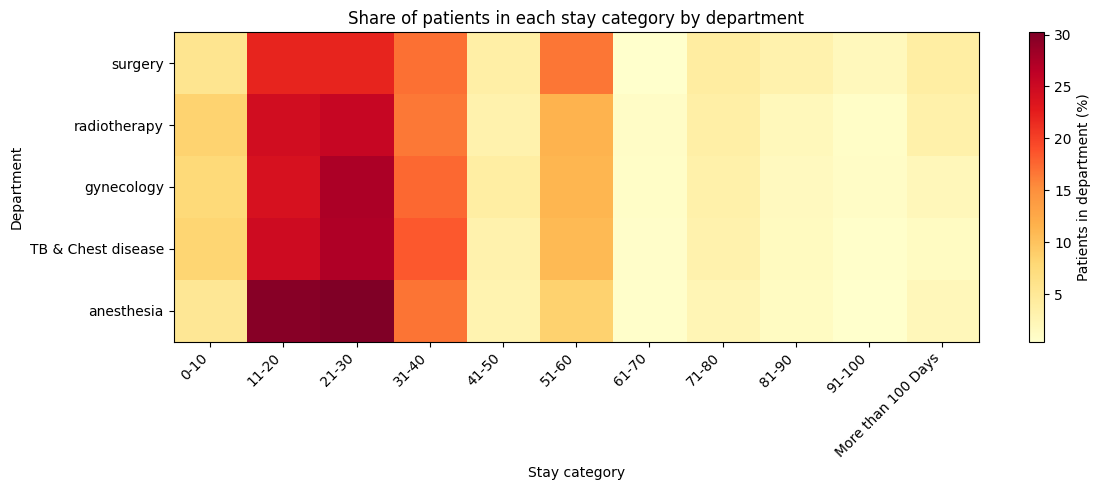

In [58]:
def show_stay_distribution_heatmap(department_stay_shares: list[dict[str, Any]]) -> None:
    """Draw a heatmap that shows how LOS categories are distributed inside each department."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("This visualisation needs matplotlib. Please run it in a notebook environment with matplotlib installed.")
        return

    departments = [row["department"] for row in department_stay_shares]
    matrix = [row["shares"] for row in department_stay_shares]

    figure, axis = plt.subplots(figsize=(12, 5))
    image = axis.imshow(matrix, cmap="YlOrRd", aspect="auto")

    axis.set_title("Share of patients in each stay category by department")
    axis.set_xlabel("Stay category")
    axis.set_ylabel("Department")
    axis.set_xticks(range(len(stay_order)))
    axis.set_xticklabels(stay_order, rotation=45, ha="right")
    axis.set_yticks(range(len(departments)))
    axis.set_yticklabels(departments)

    colorbar = figure.colorbar(image, ax=axis)
    colorbar.set_label("Patients in department (%)")

    plt.tight_layout()
    plt.show()

show_stay_distribution_heatmap(department_stay_shares)

## 7. Short conclusion

This final function prints the exact answer from the current CSV so it can be reused in the presentation.

In [59]:
#needed

def print_final_interpretation(
    department_los: list[dict[str, Any]],
    direct_correlations: list[dict[str, Any]],
    second_order_correlations: list[dict[str, Any]],
) -> None:
    """Print the main results as short sentences that can be used in the presentation."""
    top_department = department_los[0]
    best_direct = direct_correlations[0]
    best_interaction = second_order_correlations[0]

    print("Main finding")
    print(
        f"- {top_department['department']} has the longest average length of stay "
        f"with {top_department['mean_stay_days']:.1f} days."
    )
    print()
    print("Direct correlation")
    print(
        f"- Inside {top_department['department']}, the strongest direct correlation with LOS is "
        f"{best_direct['label']} ({best_direct['correlation']:.2f})."
    )
    print()
    print("Second-order correlation")
    print(
        f"- The strongest second-order correlation is {best_interaction['interaction']} "
        f"({best_interaction['correlation']:.2f})."
    )
    print()
    print("Careful interpretation")
    print("- Correlation does not prove causation, but it helps identify which factors are most connected to long stays.")

print_final_interpretation(department_los, direct_correlations, second_order_correlations)

Main finding
- surgery has the longest average length of stay with 38.1 days.

Direct correlation
- Inside surgery, the strongest direct correlation with LOS is Visitors with patient (0.60).

Second-order correlation
- The strongest second-order correlation is Visitors with patient x Admission deposit (0.51).

Careful interpretation
- Correlation does not prove causation, but it helps identify which factors are most connected to long stays.
